# Stage 3: MNIST Stacking / Blending

This notebook is a scaffold for the Stage 3 MNIST stacking/blending experiment. It outlines the planned workflow without running training or producing result files yet.

## 1. Motivation

Stage 2 showed that hard voting and soft voting did not outperform the strongest individual classifier. Stage 3 tests whether a learned blender can combine base model outputs better than equal-weight voting.

The key idea is to replace fixed voting rules with a simple supervised model that learns how to combine predictions from the base learners.

## 2. Experimental Design

The experiment will use three separate roles for the data:

- Base training data: fit the individual base models.
- Validation data: collect base model predictions and train the blender.
- Test data: evaluate the final individual models, voting baselines, and stacking/blending ensemble.

The test set must not be used to train either the base models or the blender. Keeping this separation avoids data leakage and gives a more honest final evaluation.

## 3. Imports and Configuration

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_CLASSES = 10

## 4. Load MNIST Data

This section follows the same MNIST loading and split logic as Stage 2 so the stacking/blending results remain comparable. Fast mode is the default for local iteration; set `FAST_MODE = False` to use the full book-style split.

- Fast mode: 20,000 train, 5,000 validation, 10,000 test
- Full mode: 50,000 train, 10,000 validation, 10,000 test

For Stage 3, the training split fits the base models, the validation split trains the blender, and the test split is reserved for final evaluation.

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

FAST_MODE = True

if FAST_MODE:
    N_TRAIN = 20_000
    N_VALIDATION = 5_000
    N_TEST = 10_000
else:
    N_TRAIN = 50_000
    N_VALIDATION = 10_000
    N_TEST = 10_000


def load_mnist_splits(n_train, n_validation, n_test, random_state=42):
    """Load MNIST and return train, validation, and test splits."""
    X, y = fetch_openml("mnist_784", version=1, as_frame=False, return_X_y=True)
    X = X.astype("float32") / 255.0
    y = y.astype("int64")

    total_size = n_train + n_validation + n_test
    if total_size < len(X):
        X, _, y, _ = train_test_split(
            X,
            y,
            train_size=total_size,
            random_state=random_state,
            stratify=y,
        )

    validation_and_train_size = n_train + n_validation
    X_train_valid, X_test, y_train_valid, y_test = train_test_split(
        X,
        y,
        train_size=validation_and_train_size,
        test_size=n_test,
        random_state=random_state,
        stratify=y,
    )

    validation_fraction = n_validation / validation_and_train_size
    X_train, X_validation, y_train, y_validation = train_test_split(
        X_train_valid,
        y_train_valid,
        test_size=validation_fraction,
        random_state=random_state,
        stratify=y_train_valid,
    )

    return X_train, X_validation, X_test, y_train, y_validation, y_test


X_train, X_validation, X_test, y_train, y_validation, y_test = load_mnist_splits(
    N_TRAIN,
    N_VALIDATION,
    N_TEST,
    random_state=RANDOM_STATE,
)

print(f"Train shape:      X={X_train.shape}, y={y_train.shape}")
print(f"Validation shape: X={X_validation.shape}, y={y_validation.shape}")
print(f"Test shape:       X={X_test.shape}, y={y_test.shape}")

Train shape:      X=(20000, 784), y=(20000,)
Validation shape: X=(5000, 784), y=(5000,)
Test shape:       X=(10000, 784), y=(10000,)


## 5. Define Base Models

The goal is to reuse model families comparable to Stage 2, not to tune a new set of models yet. These definitions create unfitted estimators only. Fitting happens later on the base training split.

For the blender feature step, it is useful to track which models naturally provide class probabilities and which models provide decision scores.

In [3]:
def make_base_models(random_state=42):
    """Create the unfitted base models for the Stage 3 blender."""
    return {
        "Extra-Trees": ExtraTreesClassifier(
            n_estimators=100,
            n_jobs=-1,
            random_state=random_state,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            n_jobs=-1,
            random_state=random_state,
        ),
        "Linear SVM-like SGD": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "model",
                    SGDClassifier(
                        loss="hinge",
                        max_iter=1000,
                        tol=1e-3,
                        random_state=random_state,
                    ),
                ),
            ]
        ),
        "Logistic Regression": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=200,
                        n_jobs=-1,
                        random_state=random_state,
                    ),
                ),
            ]
        ),
    }


base_models = make_base_models(random_state=RANDOM_STATE)

base_model_output_types = {
    "Extra-Trees": "predict_proba",
    "Random Forest": "predict_proba",
    "Linear SVM-like SGD": "decision_function",
    "Logistic Regression": "predict_proba",
}

base_models

{'Extra-Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Linear SVM-like SGD': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', SGDClassifier(random_state=42))]),
 'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  LogisticRegression(max_iter=200, n_jobs=-1, random_state=42))])}

## 6. Fit Base Models

Base models should be fitted only on the base training set. The validation set should be reserved for constructing blender training data.

In [4]:
fitted_base_models = {}

for model_name, model in base_models.items():
    print(f"Fitting {model_name}...")
    fitted_base_models[model_name] = model.fit(X_train, y_train)

print("Fitted base models:")
for model_name in fitted_base_models:
    print(f"- {model_name}")

Fitting Extra-Trees...
Fitting Random Forest...
Fitting Linear SVM-like SGD...
Fitting Logistic Regression...
Fitted base models:
- Extra-Trees
- Random Forest
- Linear SVM-like SGD
- Logistic Regression


## 7. Build Blender Features from Validation Predictions

Each base model will produce class probabilities or decision scores on the validation set. These outputs become the input features for the blender.

For MNIST with `K = 10` classes and `M` base models, probability features have dimension approximately `M x K`.

For base model `m`, write its prediction vector as:

`p_m(x) = (p_{m,0}(x), ..., p_{m,9}(x))`

The blender feature vector is the concatenation of the base model outputs:

`z(x) = [p_1(x), ..., p_M(x)]`

If the hinge-loss SGD classifier does not provide probabilities, it may need calibration or may contribute decision-score features instead.

In [5]:
def build_blender_features(fitted_models, X, output_types):
    """Build blender features from fitted base model probabilities or scores."""
    feature_blocks = []

    for model_name, model in fitted_models.items():
        output_type = output_types[model_name]

        if output_type == "predict_proba":
            model_features = model.predict_proba(X)
        elif output_type == "decision_function":
            model_features = model.decision_function(X)
        else:
            raise ValueError(f"Unknown output type for {model_name}: {output_type}")

        model_features = np.asarray(model_features)
        if model_features.ndim == 1:
            model_features = model_features.reshape(-1, 1)

        feature_blocks.append(model_features)

    return np.hstack(feature_blocks)


Z_validation = build_blender_features(
    fitted_base_models,
    X_validation,
    base_model_output_types,
)
Z_test = build_blender_features(
    fitted_base_models,
    X_test,
    base_model_output_types,
)

print(f"Z_validation shape: {Z_validation.shape}")
print(f"Z_test shape:       {Z_test.shape}")

Z_validation shape: (5000, 40)
Z_test shape:       (10000, 40)


## 8. Train Blender

The first blender should be a simple multinomial Logistic Regression model. The blender is trained on validation predictions, not on test predictions.

The blender should stay simple because the goal is to learn combination weights rather than overfit the validation set.

In [6]:
blender = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    random_state=42,
)

blender.fit(Z_validation, y_validation)

C:\Users\kuli1\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\kuli1\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


## 9. Test Evaluation

The final evaluation should compare:

- Best individual classifier
- Hard voting
- Soft voting
- Stacking/blending

Use the same metrics as Stage 2:

- Accuracy
- Macro F1
- Test error rate

In [7]:
def compute_test_metrics(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    return {
        "model": model_name,
        "accuracy_test": accuracy,
        "macro_f1_test": f1_score(y_true, y_pred, average="macro"),
        "test_error_rate": 1.0 - accuracy,
    }


def manual_hard_vote(models, X):
    predictions = np.array([model.predict(X) for model in models])
    return np.apply_along_axis(
        lambda votes: np.bincount(votes.astype(int)).argmax(),
        axis=0,
        arr=predictions,
    )


def manual_soft_vote(models, X):
    probabilities = np.array([model.predict_proba(X) for model in models])
    mean_probabilities = probabilities.mean(axis=0)
    return mean_probabilities.argmax(axis=1)


extra_trees_pred = fitted_base_models["Extra-Trees"].predict(X_test)
random_forest_pred = fitted_base_models["Random Forest"].predict(X_test)

hard_voting_model_names = [
    "Extra-Trees",
    "Random Forest",
    "Linear SVM-like SGD",
    "Logistic Regression",
]
soft_voting_model_names = [
    "Extra-Trees",
    "Random Forest",
    "Logistic Regression",
]

hard_voting_models = [fitted_base_models[name] for name in hard_voting_model_names]
soft_voting_models = [fitted_base_models[name] for name in soft_voting_model_names]

hard_voting_pred = manual_hard_vote(hard_voting_models, X_test)
soft_voting_pred = manual_soft_vote(soft_voting_models, X_test)
stacking_pred = blender.predict(Z_test)

stage3_results = pd.DataFrame(
    [
        compute_test_metrics("Extra Trees", y_test, extra_trees_pred),
        compute_test_metrics("Random Forest", y_test, random_forest_pred),
        compute_test_metrics("Hard Voting", y_test, hard_voting_pred),
        compute_test_metrics("Soft Voting", y_test, soft_voting_pred),
        compute_test_metrics("Stacking", y_test, stacking_pred),
    ]
)

stage3_results

,model,accuracy_test,macro_f1_test,test_error_rate
0,Extra Trees,0.9613,0.960954,0.0387
1,Random Forest,0.9572,0.956892,0.0428
2,Hard Voting,0.9493,0.948822,0.0507
3,Soft Voting,0.9347,0.933967,0.0653
4,Stacking,0.9547,0.954243,0.0453


## 10. Blender Coefficient Analysis

The fitted Logistic Regression blender stores its learned weights in `coef_`. If the blender is wrapped in a scikit-learn Pipeline, those coefficients can be accessed with `blender.named_steps["model"].coef_`. For this MNIST experiment, the coefficient matrix should have shape `(10, 40)`:

- 10 rows: one coefficient vector for each MNIST digit class
- 40 columns: one column for each meta-feature
- 4 base learners x 10 outputs per learner = 40 meta-features

The columns can be grouped by base learner. Larger average absolute coefficient magnitude indicates stronger influence on the blender decision.

Blender coefficient shape: (10, 40)


,base_model,average_abs_coefficient
0,Extra Trees,0.655290
1,Random Forest,0.612021
2,Linear SVM-like SGD,0.000759
3,Logistic Regression,0.278012


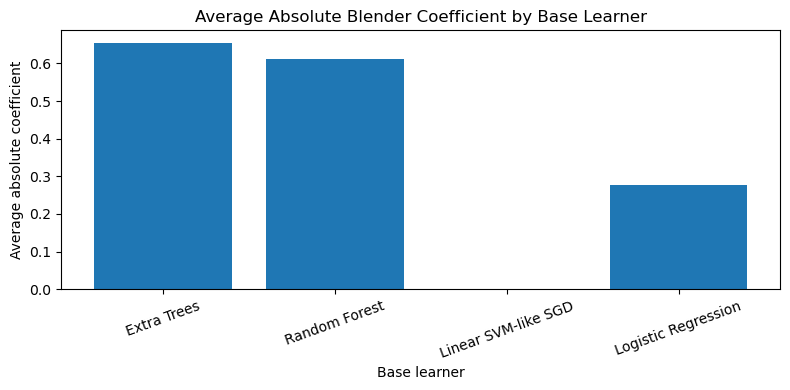

In [8]:
if hasattr(blender, "named_steps"):
    blender_coefficients = blender.named_steps["model"].coef_
else:
    blender_coefficients = blender.coef_

print(f"Blender coefficient shape: {blender_coefficients.shape}")

coefficient_groups = {
    "Extra Trees": blender_coefficients[:, 0:10],
    "Random Forest": blender_coefficients[:, 10:20],
    "Linear SVM-like SGD": blender_coefficients[:, 20:30],
    "Logistic Regression": blender_coefficients[:, 30:40],
}

coefficient_summary = pd.DataFrame(
    [
        {
            "base_model": model_name,
            "average_abs_coefficient": np.abs(coef_group).mean(),
        }
        for model_name, coef_group in coefficient_groups.items()
    ]
)

display(coefficient_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    coefficient_summary["base_model"],
    coefficient_summary["average_abs_coefficient"],
)

ax.set_title("Average Absolute Blender Coefficient by Base Learner")
ax.set_xlabel("Base learner")
ax.set_ylabel("Average absolute coefficient")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

## 11. Results Summary

The Stage 3 experiment evaluates stacking performance on MNIST.

A Logistic Regression blender is trained on base model predictions from:
- Extra Trees
- Random Forest
- Linear SVM-like SGD
- Logistic Regression

The stacking model is compared with individual tree-based models and voting ensembles using accuracy, macro F1-score, and test error rate.

The results show that stacking improves over simple voting approaches, but Extra Trees and Random Forest remain the strongest individual learners.

The blender coefficient analysis indicates that Extra Trees and Random Forest receive larger absolute coefficients, suggesting that tree-based models contribute most to the final prediction.